In [460]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
import math
from sklearn.model_selection import KFold

nltk.download('wordnet')
nltk.download('stopwords')



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [461]:
def load_and_merge_csv(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    df_list = []
    
    for file in all_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, usecols=['movie_id', 'movie_name', 'description', 'genre'])
        df_list.append(df)
    
    # Concatenate all dataframes
    merged_df = pd.concat(df_list, ignore_index=True).drop_duplicates()
    
    # One-hot encoding of genres
    genre_dummies = merged_df['genre'].str.get_dummies(sep=', ')
    
    # Merge one-hot encoded genres with main dataframe
    final_df = pd.concat([merged_df.drop(columns=['genre']), genre_dummies], axis=1)
    
    return final_df

# Example usage
folder_path = r"C:\Users\abhay\Movie_classification\3"  
final_df = load_and_merge_csv(folder_path)

In [462]:
display(final_df)

,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
0,tt9114286,Black Panther: Wakanda Forever,The people of Wakanda fight to protect their h...,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,tt1630029,Avatar: The Way of Water,Jake Sully lives with his newfound family form...,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,tt5884796,Plane,A pilot finds himself caught in a war zone aft...,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,tt6710474,Everything Everywhere All at Once,A middle-aged Chinese immigrant is swept up in...,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,tt5433140,Fast X,Dom Toretto and his family are targeted by the...,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368291,tt0009655,Stolen Orders,A renegade American and his innocent daughter ...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368294,tt26684378,Dalilah,Add a Plot,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368296,tt26690183,World War 1 project,Add a Plot,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368297,tt26695367,74,"74 centres on the lives of four women, and the...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [463]:
final_df.shape

(243715, 30)

In [464]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243715 entries, 0 to 368299
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   movie_id     243715 non-null  object
 1   movie_name   243713 non-null  object
 2   description  243715 non-null  object
 3   Action       243715 non-null  int64 
 4   Adult        243715 non-null  int64 
 5   Adventure    243715 non-null  int64 
 6   Animation    243715 non-null  int64 
 7   Biography    243715 non-null  int64 
 8   Comedy       243715 non-null  int64 
 9   Crime        243715 non-null  int64 
 10  Drama        243715 non-null  int64 
 11  Family       243715 non-null  int64 
 12  Fantasy      243715 non-null  int64 
 13  Film-Noir    243715 non-null  int64 
 14  Game-Show    243715 non-null  int64 
 15  History      243715 non-null  int64 
 16  Horror       243715 non-null  int64 
 17  Music        243715 non-null  int64 
 18  Musical      243715 non-null  int64 
 19  Mystery

In [465]:
missing_rows = final_df[final_df['movie_name'].isnull()]
display(missing_rows)

,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
14130,tt5774076,NaN,Two boys throw a party while their parents are...,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354393,tt17042812,NaN,"A survival game show on the web, abandons cont...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [466]:
final_df['movie_name'].fillna("Unknown", inplace=True)

C:\Users\abhay\AppData\Local\Temp\ipykernel_3996\1054287886.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['movie_name'].fillna("Unknown", inplace=True)


In [467]:
final_df = final_df.reset_index(drop=True)

In [468]:
# Check for duplicate movie_id values
duplicate_movie_ids = final_df[final_df.duplicated(subset=['movie_id'], keep=False)]

if duplicate_movie_ids.empty:
    print("All movie_id values are unique. It behaves like a primary key.")
else:
    print(f"Found {len(duplicate_movie_ids)} duplicate movie_id values. It does not behave like a primary key.")
    display(duplicate_movie_ids)  # Display the duplicate rows


Found 1036 duplicate movie_id values. It does not behave like a primary key.


,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
560,tt15326988,Ghosted,Plot under wraps.,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
603,tt8589698,Teenage Mutant Ninja Turtles: Mutant Mayhem,CG-animated feature film based on the superher...,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
773,tt0108333,The Three Musketeers,"France, 1625: Young d'Artagnan heads to Paris ...",1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1345,tt12965390,Perfect Addiction,A Successful boxing trainer discovers that her...,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1493,tt0286112,Shaolin Soccer,A young Shaolin follower reunites with his dis...,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240561,tt0042977,The Horsemen,The rival of a worker on a Cossack stud farm e...,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
240602,tt0049180,Embajadores en el Infierno,Spanish right-wingers equally devoted to Catho...,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
240742,tt0211380,The Fuhrer Runs Amok,France and Germany are at war. Adolf Hitler ch...,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
241294,tt10542800,Ohi Day - Freedom or Death,Dramatic love story in Greece during World War...,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [469]:
# Group by 'movie_id', keep the first occurrence of 'movie_name' and 'description'
final_df = final_df.groupby('movie_id', as_index=False).agg({
    'movie_name': 'first',      # Keep first occurrence of movie_name
    'description': 'first',     # Keep first occurrence of description
    **{col: 'max' for col in final_df.columns if col not in ['movie_id', 'movie_name', 'description']}
})

# Check if duplicates are removed
print(final_df['movie_id'].duplicated().sum())  # Should be 0


0


In [470]:
# Check for duplicate movie_id values
duplicate_movie_ids = final_df[final_df.duplicated(subset=['movie_id'], keep=False)]

if duplicate_movie_ids.empty:
    print("All movie_id values are unique. It behaves like a primary key.")
else:
    print(f"Found {len(duplicate_movie_ids)} duplicate movie_id values. It does not behave like a primary key.")
    display(duplicate_movie_ids)  # Display the duplicate rows


All movie_id values are unique. It behaves like a primary key.


In [471]:
final_df.shape

(243197, 30)

In [472]:
# Reset index to ensure proper sequential indexing
final_df = final_df.reset_index(drop=True)

In [473]:
print(final_df.index)  # Should be a range from 0 to (number of rows - 1)
display(final_df.head())  # Display first few rows to confirm

RangeIndex(start=0, stop=243197, step=1)


,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
0,tt0000009,Miss Jerry,The adventures of a female reporter in the 1890s.,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,tt0000574,The Story of the Kelly Gang,"Story of Ned Kelly, an infamous 19th-century A...",1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,tt0000679,The Fairylogue and Radio-Plays,L. Frank Baum would appear in a white suit and...,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,tt0001049,Gøngehøvdingen,Add a Plot,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,tt0001115,Ansigttyven I,Consul Bjørn is urgently called to a company m...,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [474]:
# Exclude non-category columns
category_columns = final_df.columns.drop(['movie_id', 'movie_name', 'description'])

# Convert genre columns to category datatype
for col in category_columns:
    final_df[col] = final_df[col].astype('category')


In [475]:
sum_genre = final_df[category_columns].astype(int).sum()

df_movies_per_genre = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre.values})



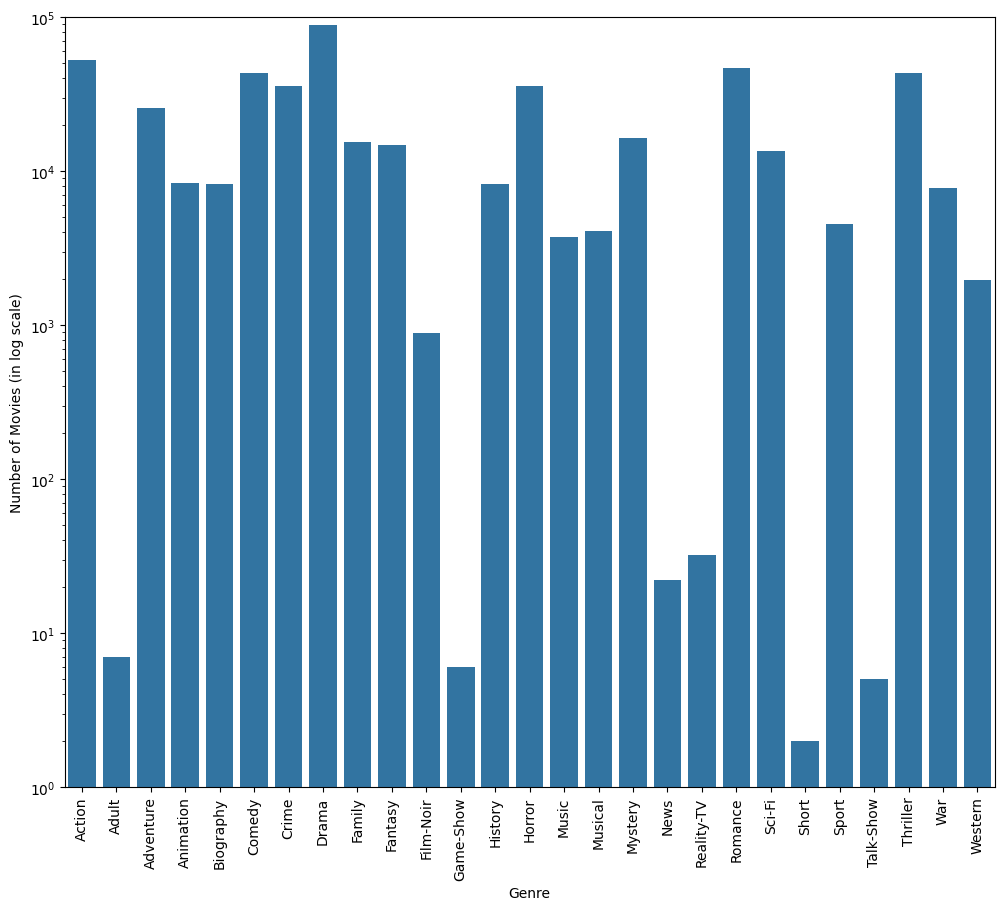

In [476]:
f, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.barplot(data=df_movies_per_genre, x='Genre', y='Total', ax=ax)
ax.set(yscale='log', ylim=(1, 1e5), ylabel='Number of Movies (in log scale)')
plt.xticks(rotation=90)
plt.show()

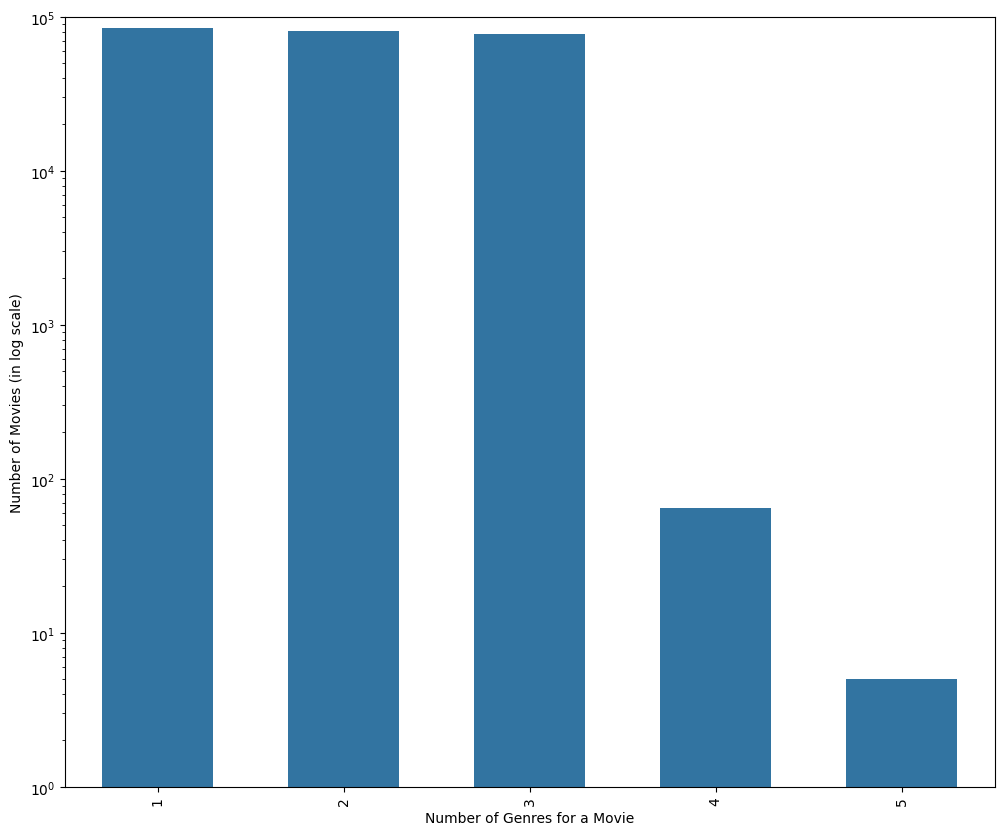

In [477]:
sum_movie = final_df[category_columns].astype(int).sum(axis=1)
df_genres_per_movie = pd.DataFrame({'movie_name': final_df.movie_name, 'num_genres': sum_movie}).groupby('num_genres').count()

f, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.barplot(data=df_genres_per_movie, x=df_genres_per_movie.index, y='movie_name', ax=ax, width=0.6)  
ax.set(yscale='log', ylim=(1, 1e5), xlabel='Number of Genres for a Movie', ylabel='Number of Movies (in log scale)')
plt.xticks(rotation=90)
plt.show()


In [478]:
def remove_accents(sentence):
    cleaned_sentence = unicodedata.normalize('NFD', sentence)
    cleaned_sentence = cleaned_sentence.encode('ascii', 'ignore')
    cleaned_sentence = cleaned_sentence.decode("utf-8")
    return cleaned_sentence

In [479]:
def remove_accents(text):
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode("utf-8")
    return text

In [480]:
def remove_punctuation(text):
    text = re.sub(r'[?|!|\'|"|#]', '', text)
    text = re.sub(r'[,|.|;|:|(|)|{|}|\|/|<|>]|-', ' ', text)
    text = text.replace("\n", " ")
    return text

In [481]:
def keep_alpha(text):
    text = re.sub('[^a-zA-Z ]+', ' ', text)
    return text

In [482]:
def lower_case(text):
    return text.lower()

In [483]:
def lemmatize_words(sentence):
    lem = WordNetLemmatizer()
    lemmatized_words = [lem.lemmatize(word, 'v') for word in sentence.split()]
    return ' '.join(lemmatized_words)

In [484]:
def remove_stop_words(sentence):
    stop_words = set(stopwords.words('english'))
    stop_words.update(['add','plot','summary','full','see','life','story','life','live','find','young'])
    no_stop_words = [word for word in sentence.split() if word not in stop_words]
    return ' '.join(no_stop_words)

In [485]:
def text_preprocess(sentence):
    pre_processed_sentence = remove_accents(sentence)
    pre_processed_sentence = remove_punctuation(pre_processed_sentence)
    pre_processed_sentence = keep_alpha(pre_processed_sentence)
    pre_processed_sentence = lower_case(pre_processed_sentence)
    pre_processed_sentence = lemmatize_words(pre_processed_sentence)
    pre_processed_sentence = remove_stop_words(pre_processed_sentence)
    
    return pre_processed_sentence


In [486]:
final_df['description'] = final_df['description'].apply(text_preprocess)

In [487]:
def display_wordcloud_plots(data, labels):
    for col in labels:
        wordcloud = WordCloud(max_font_size=50).generate(' '.join(data[data[col] == 1]['plot']))
        plt.figure(figsize=(9, 9))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f'Movie Genre: {col}')
        plt.show()

def display_wordcloud_subplots(data, labels):
    num_cols = 2
    num_rows = math.ceil(len(labels) / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 20))
    axes = axes.flatten()

    for idx, col in enumerate(labels):
        wordcloud = WordCloud(max_font_size=50).generate(' '.join(data[data[col] == 1]['plot']))
        axes[idx].imshow(wordcloud, interpolation="bilinear")
        axes[idx].axis("off")
        axes[idx].set_title(f'Movie Genre: {col}')

    for ax in axes[len(labels):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


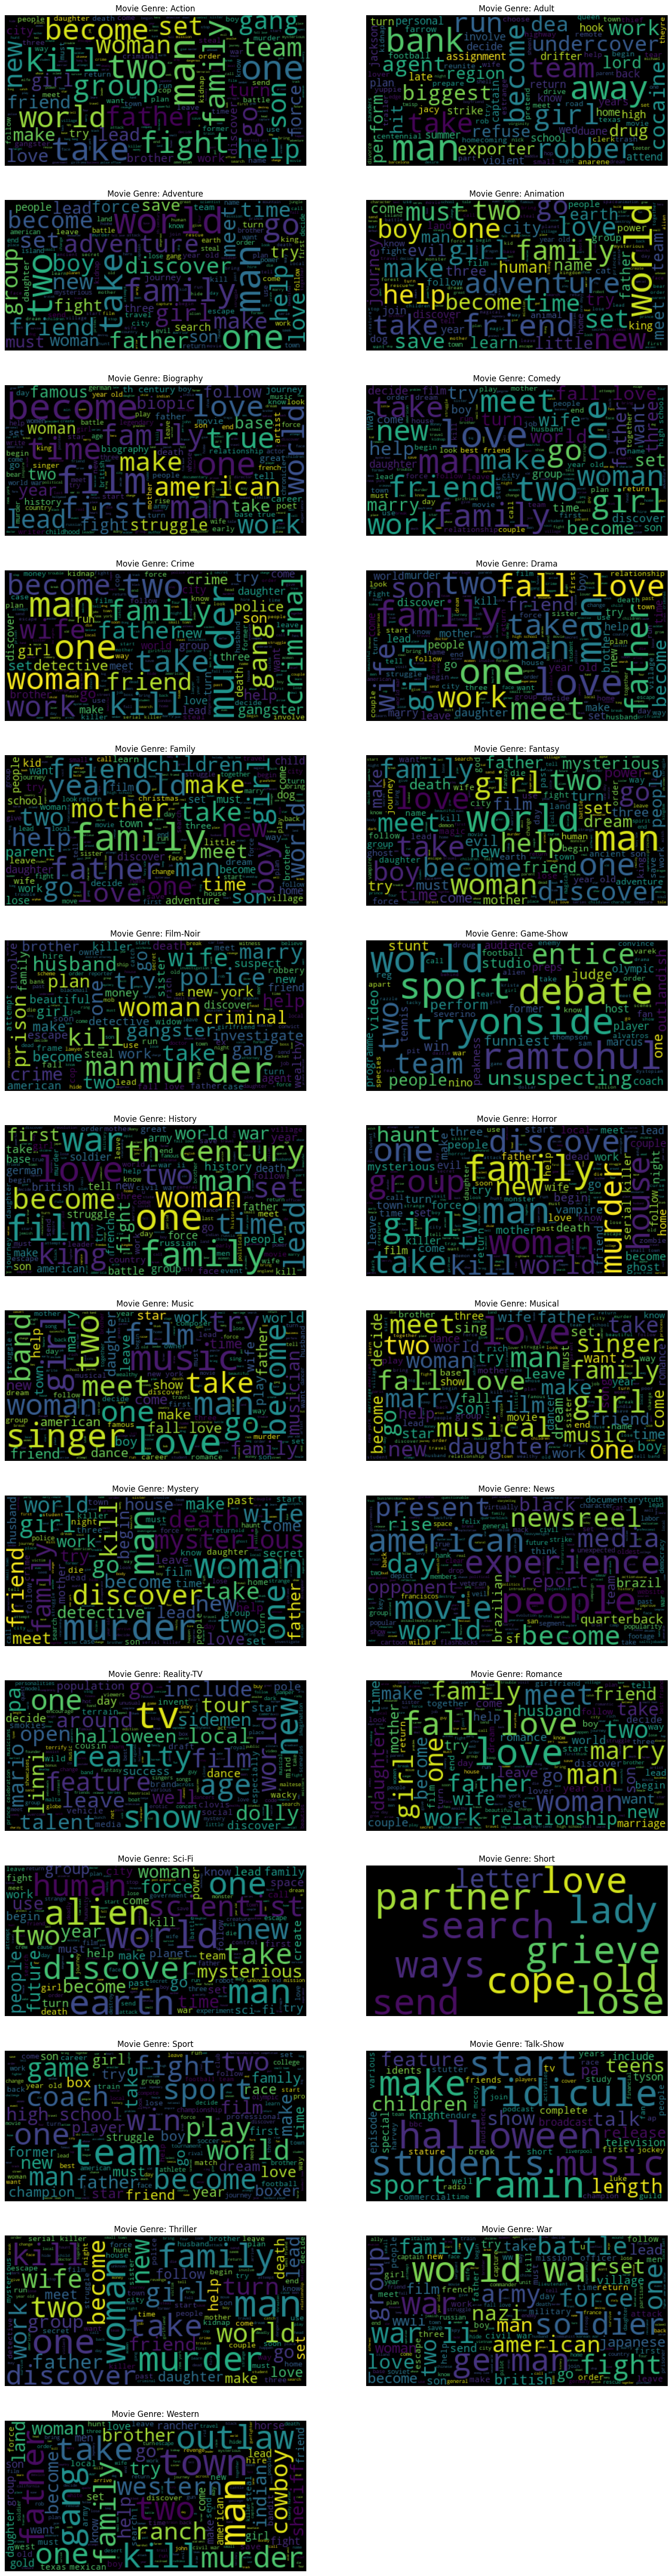

In [488]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math

fig = plt.figure(figsize=(18, 70))
num_cols = 2
num_rows = math.ceil(len(category_columns) / num_cols)

for idx, col in enumerate(category_columns):
    wordcloud = WordCloud(max_font_size=50).generate(' '.join(final_df[final_df[col] == 1]['description']))
    ax = fig.add_subplot(num_rows, num_cols, idx + 1)
    ax.imshow(wordcloud)
    ax.axis("off")
    ax.set(title=f'Movie Genre: {col}')

plt.show()


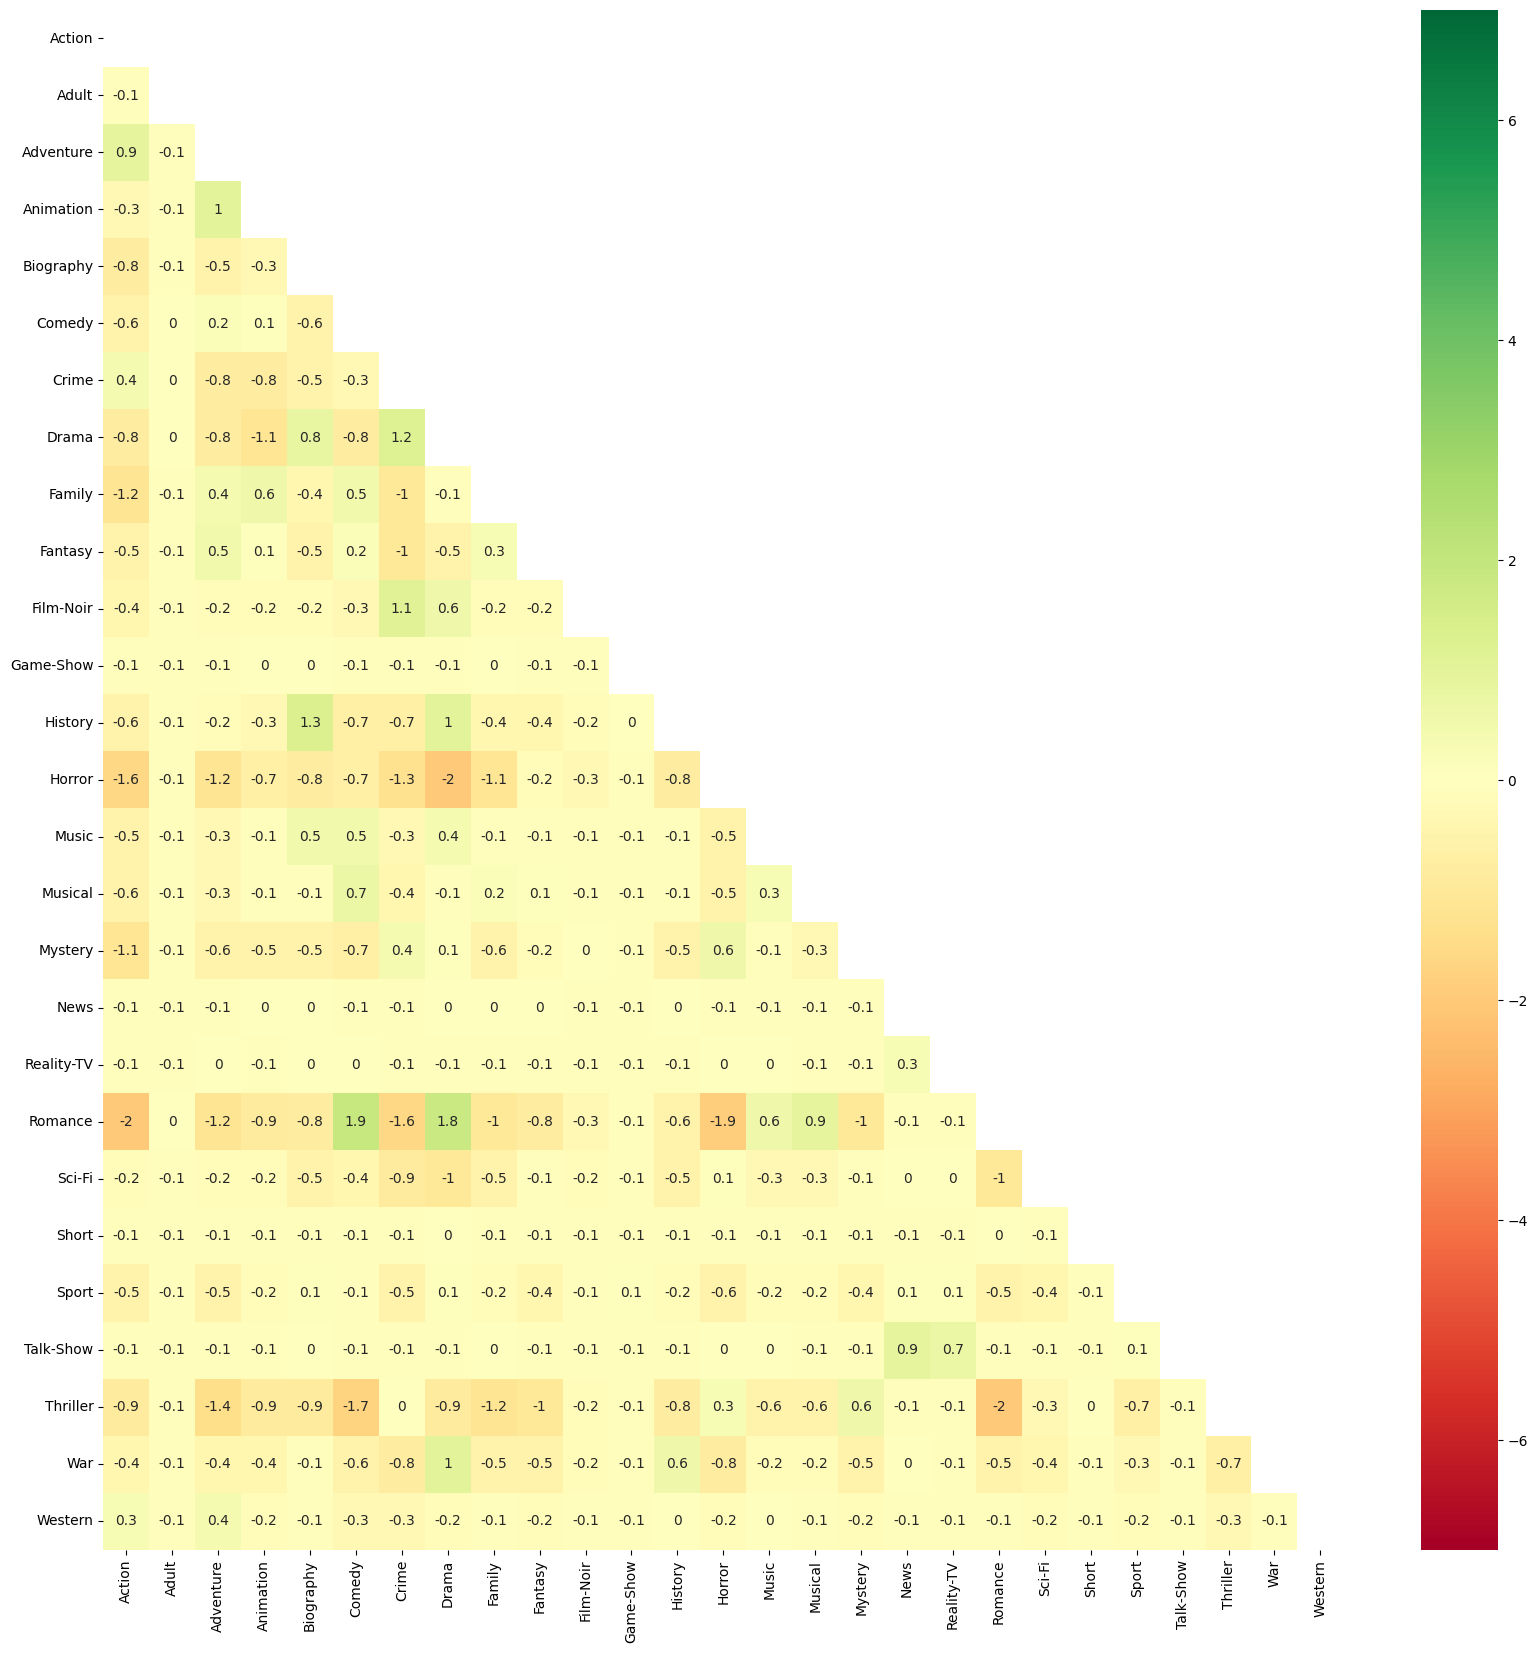

In [489]:
corr_matrix = final_df[category_columns].astype(int).corr()

# Create a mask for the lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Scale correlation values for better readability
corr_matrix = (100 * corr_matrix // 1) / 10

# Plot the heatmap
fig = plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, mask=mask, annot=True, cbar=True, vmax=7, vmin=-7, cmap='RdYlGn')

plt.show()

In [490]:
def multi_label_train_test_split(final_df, category_columns, min_test_size=0.15, shuffle=True, random_state=29):
    data_size = final_df.shape[0]
    
    # Boolean mask for test data
    data_test_idx = np.array([False] * data_size)

    # Number of folds
    n_folds = math.floor(1 / min_test_size)
    
    # Track rows to be completely excluded
    exclude_idx = np.array([False] * data_size)

    for col in category_columns:
        # Get all rows where the label is present
        data_curr_genre = final_df[final_df[col] == 1]
        curr_genre_size = data_curr_genre.shape[0]
        
        # Exclude genres with fewer than 10 movies
        if curr_genre_size < 6:
            exclude_idx[data_curr_genre.index] = True
            continue
        
        # Compute test set size for this label
        curr_test_size = math.ceil(curr_genre_size * min_test_size)

        # KFold cross-validation
        kf = KFold(n_splits=min(n_folds, curr_genre_size), shuffle=shuffle, random_state=random_state)
        split_indices = list(kf.split(data_curr_genre))

        # Use the first fold for the test set
        test_indices = split_indices[0][1][:curr_test_size]

        # Map selected test indices to original data
        data_test_idx[data_curr_genre.iloc[test_indices].index] = True

    # Exclude rows belonging to rare genres
    valid_idx = ~exclude_idx

    # Split data into train and test sets, excluding rare genres
    final_test = final_df[data_test_idx & valid_idx]
    final_train = final_df[~data_test_idx & valid_idx]
    
    return final_train, final_test


In [491]:
# Running the function to get train and test datasets
final_train, final_test = multi_label_train_test_split(final_df, category_columns)

# Displaying the sizes of train and test sets
print("Train Data Shape:", final_train.shape)
print("Test Data Shape:", final_test.shape)


Train Data Shape: (178675, 30)
Test Data Shape: (64515, 30)


In [492]:
# Convert categorical columns to integers before summing
sum_genre = final_df[category_columns].astype(int).sum()
sum_genre_train = final_train[category_columns].astype(int).sum()
sum_genre_test = final_test[category_columns].astype(int).sum()

# Creating dataframes for train and test genre distributions
df_movies_per_genre_train = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre_train / sum_genre, 'Data Set': 'Train'})
df_movies_per_genre_test = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre_test / sum_genre, 'Data Set': 'Test'})

# Concatenating both datasets for visualization
df_movies_per_genre = pd.concat([df_movies_per_genre_train, df_movies_per_genre_test])

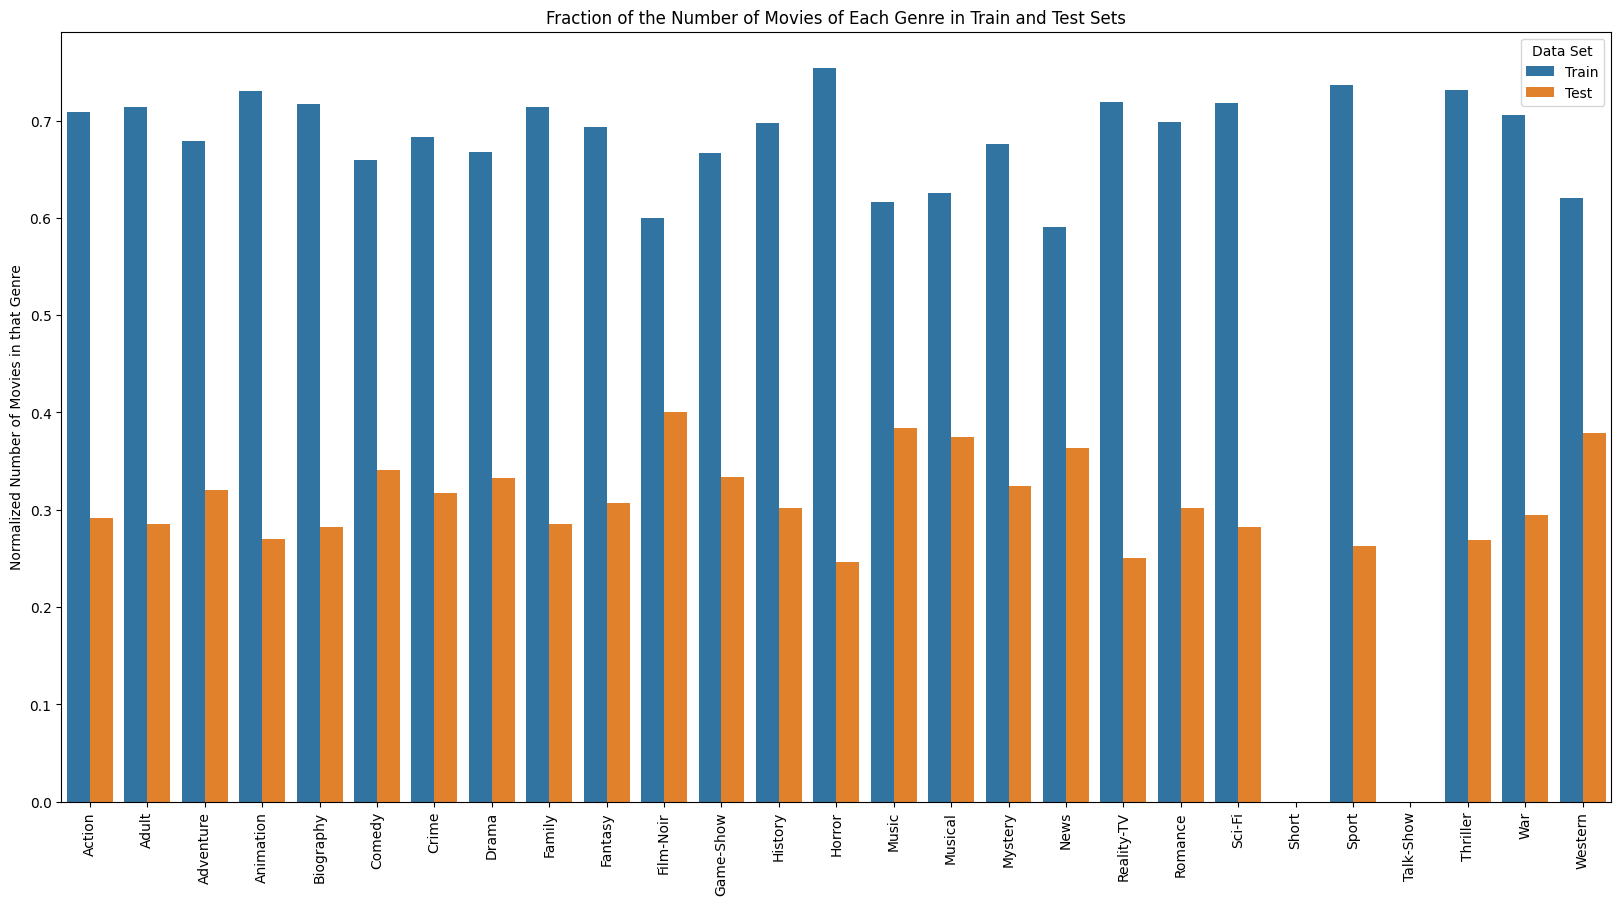

In [493]:
# Plotting the genre distribution in train and test sets
plt.figure(figsize=(20, 10))
sns.barplot(data=df_movies_per_genre, x='Genre', y='Total', hue='Data Set')
plt.ylabel('Normalized Number of Movies in that Genre')
plt.xlabel('')
plt.title('Fraction of the Number of Movies of Each Genre in Train and Test Sets')
plt.xticks(rotation=90)
plt.show()


In [494]:
# Define the labels to drop
labels_to_drop = {'Short', 'Talk-Show'}

# Filter out rows where any of the dropped labels are present
final_train = final_train[~final_train[category_columns].isin(labels_to_drop).any(axis=1)]
final_test = final_test[~final_test[category_columns].isin(labels_to_drop).any(axis=1)]

# Display updated shapes
print("Updated Train Data Shape:", final_train.shape)
print("Updated Test Data Shape:", final_test.shape)


Updated Train Data Shape: (178675, 30)
Updated Test Data Shape: (64515, 30)


In [495]:
train_X, train_y = final_train['description'], final_train.drop(['movie_id', 'movie_name', 'description'], axis=1)
test_X, test_y = final_test['description'], final_test.drop(['movie_id', 'movie_name', 'description'], axis=1)

category_columns = train_y.columns

In [496]:
train_y = train_y.to_numpy()  # If train_y is a Pandas DataFrame

In [497]:
# Ensure train_y is a NumPy array and contains only float values
train_y = train_y.astype(float)  # Convert to float (no .to_numpy())


In [498]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

lr = LogisticRegression(max_iter=500, solver='liblinear')
clf = OneVsRestClassifier(lr)

clf.fit(train_X_tfidf, train_y)  # Make sure train_y is a NumPy array


C:\Users\abhay\AppData\Roaming\Python\Python310\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 21 is present in all training examples.
  warnings.warn(
C:\Users\abhay\AppData\Roaming\Python\Python310\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 23 is present in all training examples.
  warnings.warn(


OneVsRestClassifier(estimator=LogisticRegression(max_iter=500,
                                                 solver='liblinear'))

In [499]:
# Predict on test data
y_pred = clf.predict(test_X_tfidf)

In [500]:
# Ensure test_y is a NumPy array
test_y = np.array(test_y)


In [504]:
precision = precision_score(test_y_binarized, y_pred, average='micro')
recall = recall_score(test_y_binarized, y_pred, average='micro')
f1 = f1_score(test_y_binarized, y_pred, average='micro')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


Precision: 0.7050944224857268
Recall: 0.2190851778062826
F1-score: 0.3342980885353767
